In [1]:
# NBVAL_SKIP
from jax import config
#config.update("jax_enable_x64", True)
config.update('jax_num_cpu_devices', 2)

In [2]:
#NBVAL_SKIP
import os

# Tell XLA to fake 2 host CPU devices
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=3'

# Only make GPU 0 and GPU 1 visible to JAX:
#os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3,4,5'

#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]   = "false"

import jax

# Now JAX will list two CpuDevice entries
print(jax.devices())
# → [CpuDevice(id=0), CpuDevice(id=1)]

[CpuDevice(id=0), CpuDevice(id=1)]


In [3]:
# NBVAL_SKIP
#import os
#  os.environ['SPS_HOME'] = '/mnt/storage/annalena_data/sps_fsps'
#os.environ['SPS_HOME'] = '/home/annalena/sps_fsps'
os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
#os.environ['SPS_HOME'] = '/export/home/aschaibl/fsps'
#os.environ['SPS_HOME'] = '/home/annalena_data/sps_fsps'

# RUBIX pipeline

RUBIX is designed as a linear pipeline, where the individual functions are called and constructed as a pipeline. This allows as to execude the whole data transformation from a cosmological hydrodynamical simulation of a galaxy to an IFU cube in two lines of code. This notebook shows, how to execute the pipeline. To see, how the pipeline is execuded in small individual steps per individual function, we refer to the notebook `rubix_pipeline_stepwise.ipynb`.

## How to use the Pipeline
1) Define a `config`
2) Setup the `pipeline yaml`
3) Run the RUBIX pipeline
4) Do science with the mock-data

## Step 1: Config



In [4]:
#NBVAL_SKIP
import matplotlib.pyplot as plt
from rubix.core.pipeline import RubixPipeline 
import os

config_TNG = {
    "pipeline":{"name": "calc_ifu_memory"},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "IllustrisAPI",
        "args": {
            "api_key": os.environ.get("ILLUSTRIS_API_KEY"),
            "particle_type": ["stars"],
            "simulation": "TNG50-1",
            "snapshot": 99,
            "save_data_path": "data",
        },
        
        "load_galaxy_args": {
        "id": 11,
        "reuse": True,
        },
        
        "subset": {
            "use_subset": True,
            "subset_size": 500000,
        },
    },
    "simulation": {
        "name": "IllustrisTNG",
        "args": {
            "path": "data/galaxy-id-11.hdf5",
        },
    
    },
    "output_path": "output",

    "telescope":
        {"name": "MUSE",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 0.5},
         "noise": {"signal_to_noise": 100,"noise_distribution": "normal"},},
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.1,
         "rotation": {"type": "edge-on"},
        },
        
    "ssp": {
        "template": {
            "name": "FSPS", #"Mastar_CB19_SLOG_1_5"
        },
        "dust": {
                "extinction_model": "Cardelli89",
                "dust_to_gas_ratio": 0.01,
                "dust_to_metals_ratio": 0.4,
                "dust_grain_density": 3.5,
                "Rv": 3.1,
            },
    },        
}

2025-07-02 10:19:40,907 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2025-07-02 10:19:40,908 - rubix - INFO - Rubix version: 0.0.post427+g131f0ec.d20250602
2025-07-02 10:19:40,908 - rubix - INFO - JAX version: 0.5.0
2025-07-02 10:19:40,908 - rubix - INFO - Running on [CpuDevice(id=0), CpuDevice(id=1)] devices


## Step 3: Run the pipeline

After defining the `config` and the `pipeline_config` you can simply run the whole pipeline by these two lines of code.

In [5]:
#NBVAL_SKIP
pipe = RubixPipeline(config_TNG)

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(


In [ ]:
#NBVAL_SKIP
import jax.numpy as jnp

inputdata = pipe.prepare_data()
coords = inputdata.stars.coords
vel = inputdata.stars.velocity
mass = inputdata.stars.mass
age = inputdata.stars.age
met = inputdata.stars.metallicity
factor = 10
inputdata.stars.coords = jnp.concatenate([coords]*factor, axis=0)
inputdata.stars.velocity = jnp.concatenate([vel]*factor, axis=0)
inputdata.stars.mass = jnp.concatenate([mass]*factor, axis=0)
inputdata.stars.age = jnp.concatenate([age]*factor, axis=0)
inputdata.stars.metallicity = jnp.concatenate([met]*factor, axis=0)
inputdata.stars.coords.shape

2025-07-02 10:19:41,320 - rubix - INFO - Getting rubix data...
2025-07-02 10:19:41,321 - rubix - INFO - Rubix galaxy file already exists, skipping conversion
2025-07-02 10:19:41,400 - rubix - INFO - Centering stars particles
2025-07-02 10:19:41,939 - rubix - WARNING - The Subset value is set in config. Using only subset of size 500000 for stars
2025-07-02 10:19:41,941 - rubix - INFO - Data loaded with 500000 star particles and 0 gas particles.


(200000000, 3)

In [7]:
#NBVAL_SKIP

rubixdata = pipe.run_sharded(inputdata)

2025-07-02 10:20:30,105 - rubix - INFO - Setting up the pipeline...
2025-07-02 10:20:30,108 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'filter_particles': {'name': 'filter_particles', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'filter_particles', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_psf': {'name': 'convolve_psf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'convolve_psf', 'args': [], 'kwargs': {}}, 'apply_noise': {'name': 'apply_noise', 'depends_on': 'convolve_lsf', 'args': [], 'kwargs': {}}}}
2025-07-02 10:20:30,130 - rubix - DEBUG - Roataion Type found: edge-on
2025-07-02 10:2

In [4]:
import jax.numpy as jnp
particle_number = jnp.array([1, 10, 100, 1e3, 1e4, 1e5, 5e5, 5e5*2, 5e5*20, 5e5*50, 5e5*100, 5e5*150, 5e5*200, 5e5*300, 5e5*400])
time_on_mac = jnp.array([2.14, 2.14, 2.24, 2.2, 2.2 ,2.15, 2.34, 2.26, 2.50, 3.78, 16.88, 38.92, 56.29, 72.27, 86.98]) #seconds

Text(0.5, 1.0, 'Scaling of Rubix Pipeline with Number of Particles')

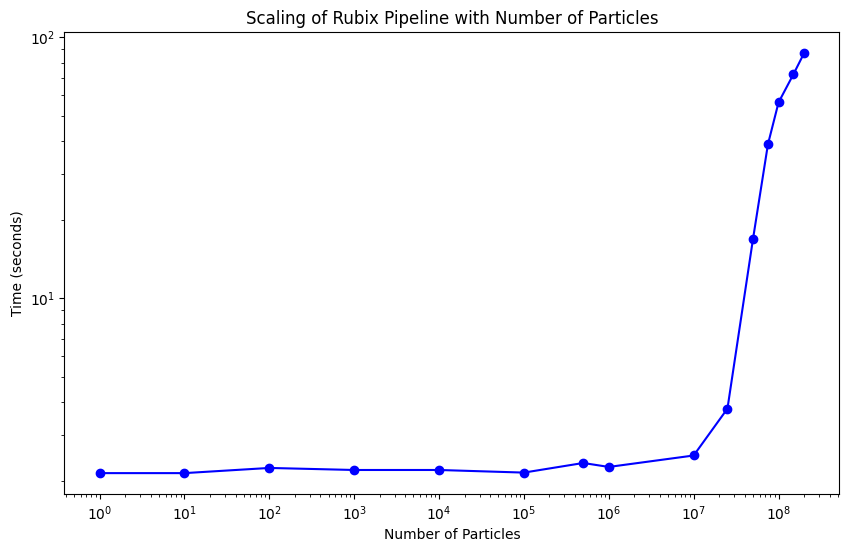

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(particle_number, time_on_mac, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Particles')
plt.ylabel('Time (seconds)')
plt.title('Scaling of Rubix Pipeline with Number of Particles')

Text(0.5, 1.0, 'Scaling of Rubix Pipeline with Number of Particles')

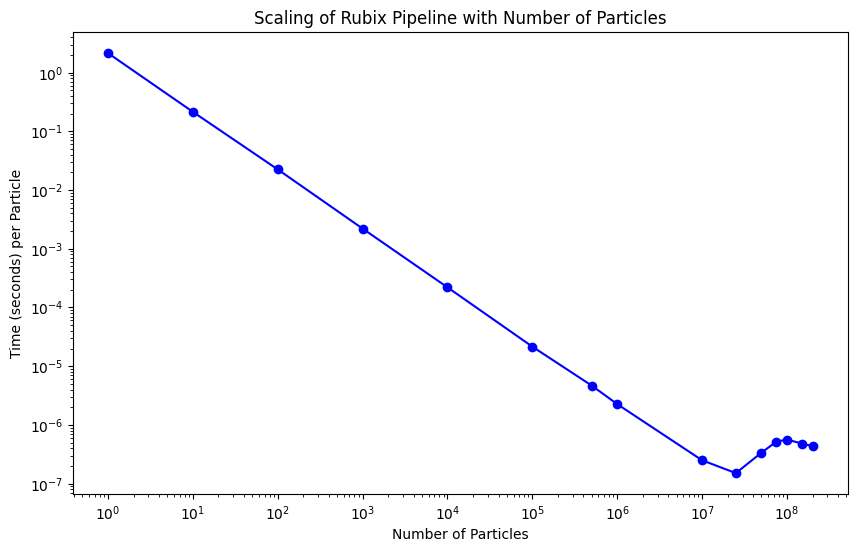

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(particle_number, time_on_mac/particle_number, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Particles')
plt.ylabel('Time (seconds) per Particle')
plt.title('Scaling of Rubix Pipeline with Number of Particles')